Clusters: [[[2, 6], [5, 6], [4, 7], [6, 6], [5, 7]], [[2, 4], [5, 2], [4, 4]], [[8, 3], [6, 3]]]
Final Centroids: [[5, 6], [4, 4], [7.0, 3.0]]


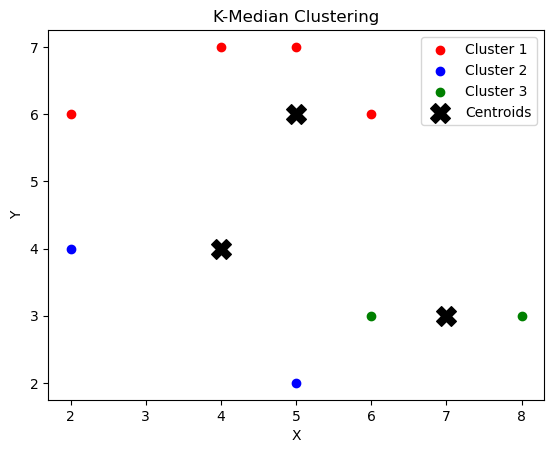

In [1]:
import matplotlib.pyplot as plt

data = [
    [2,4], [2,6], [5,6], [4,7], [8,3],
    [6,6], [5,2], [5,7], [6,3], [4,4]
]

centroids = [[1,5], [4,1], [8,4]]
k = 3
max_iters = 10


def distance(p1, p2):
    return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])


def median(values):
    values = sorted(values)
    n = len(values)

    if n % 2 == 0:
        return (values[n//2 - 1] + values[n//2]) / 2
    else:
        return values[n//2]


for _ in range(max_iters):

    clusters = [[] for _ in range(k)]

    # Assign points
    for point in data:
        distances = [distance(point, c) for c in centroids]
        cluster_index = distances.index(min(distances))
        clusters[cluster_index].append(point)

    new_centroids = []

    for cluster in clusters:
        x_vals = [p[0] for p in cluster]
        y_vals = [p[1] for p in cluster]

        new_centroids.append([median(x_vals), median(y_vals)])

    if new_centroids == centroids:
        break

    centroids = new_centroids


print("Clusters:", clusters)
print("Final Centroids:", centroids)


# Plot clusters
colors = ['red','blue','green']

for i, cluster in enumerate(clusters):
    x = [p[0] for p in cluster]
    y = [p[1] for p in cluster]
    plt.scatter(x, y, color=colors[i], label=f'Cluster {i+1}')

cx = [c[0] for c in centroids]
cy = [c[1] for c in centroids]

plt.scatter(cx, cy, color='black', marker='X', s=200, label='Centroids')

plt.title("K-Median Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()
